In [2]:
import numpy as np
import torch
import mogptk
import matplotlib.pyplot as plt


#from tests.scalability import output_dims

torch.manual_seed(1);

In [3]:
# Generar entradas
N = 200
X = np.linspace(0, 1, N).reshape(-1, 1)

# Función latente
f = np.sin(2*np.pi*X)*np.sin(6*np.pi*X)

# Varianza heterocedástica
sigma2_X = 0.02 + 0.4 * X**2
sigma_X = np.sqrt(sigma2_X)

# Generar ruido heterocedástico
noise = np.random.randn(N, 1) * sigma_X

# Salidas observadas (datos con ruido)
Y = f + noise
Y = Y.reshape(-1, 1)

In [4]:
print(X.shape)   # (200, 1)
print(Y.shape)   # (200, 1)


(200, 1)
(200, 1)


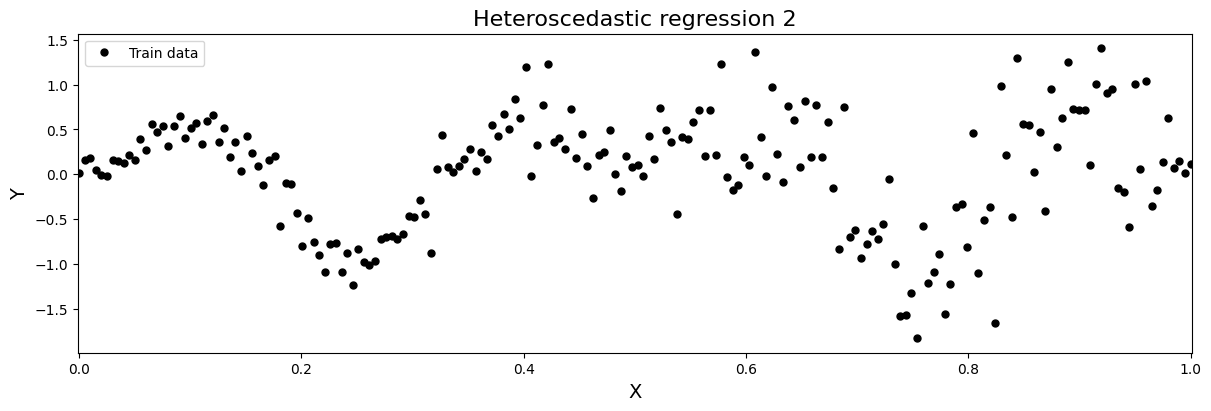

In [5]:
data = mogptk.DataSet(
    mogptk.Data(X, Y, name="Heteroscedastic regression"),
    mogptk.Data(X, Y, name="Heteroscedastic regression 2"),
)
data[1].plot();

In [6]:
# Kernel para la media
k_f = mogptk.gpr.MaternKernel()
k_f.lengthscale.assign(0.3)
k_f.magnitude.assign(0.3)
# Kernel para la log-varianza
k_g = mogptk.gpr.SquaredExponentialKernel()
k_g.lengthscale.assign(0.1)
k_g.magnitude.assign(0.3)
kernel = mogptk.gpr.LinearModelOfCoregionalizationKernel(
    k_f,
    k_g,
    output_dims=2
)

In [7]:
likelihood = mogptk.gpr.MultiLatentLikelihood(
    mogptk.gpr.GaussianHeteroLikelihood()
)

In [8]:
inference = mogptk.Hensman(likelihood=likelihood)

In [9]:
model = mogptk.Model(data, kernel, inference=inference)

Starting optimization using Adam
‣ Model: Hensman
  ‣ Kernel: LinearModelOfCoregionalizationKernel[MaternKernel,SquaredExponentialKernel]
  ‣ Likelihood: MultiLatent[GaussianHeteroLikelihood, Q=2]
‣ Channels: 2
‣ Parameters: 80608
‣ Training points: 400
‣ Iterations: 1000
     0/1000   0:00:00  loss=     323.413


C:\Users\Usuario UTP\Documents\Doctorado\mogptk\mogptk\model.py:384: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return float(self.gpr.loss())


   355/1000   0:00:10  loss=     83.0767
   723/1000   0:00:20  loss=     61.8573
  1000/1000   0:00:27  loss=     57.2101
Optimization finished in 27.569 seconds


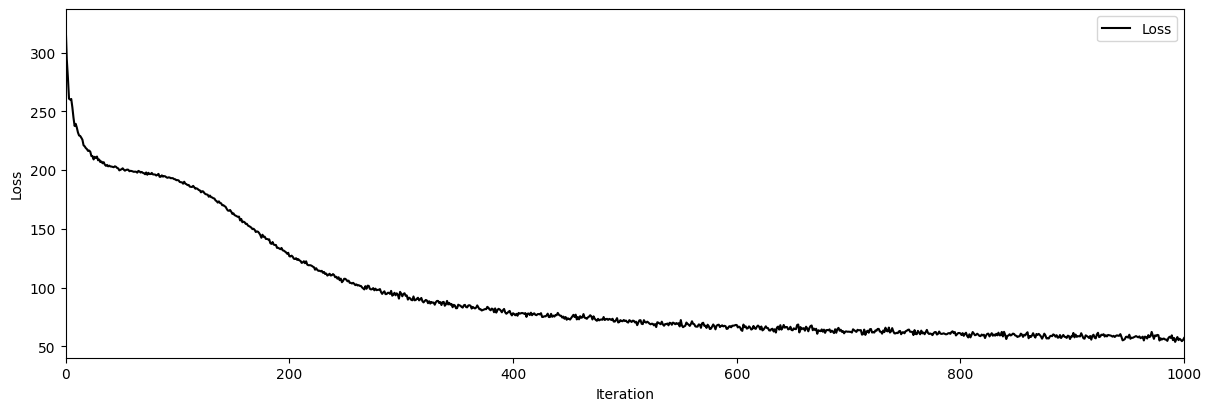

In [10]:
model.train(iters=1000, verbose=True, lr=0.01, jit = False)
model.plot_losses();

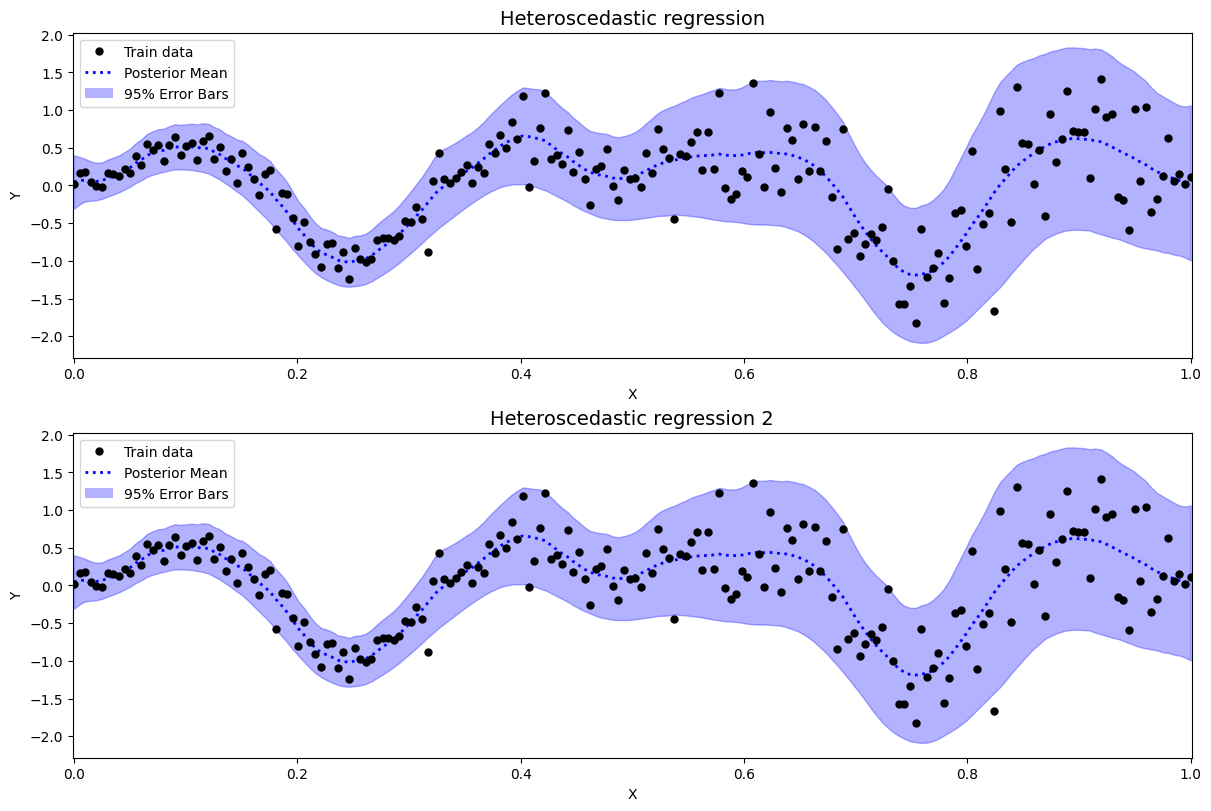

In [12]:
model.plot_prediction(n=100000);

Detected: heteroscedastic


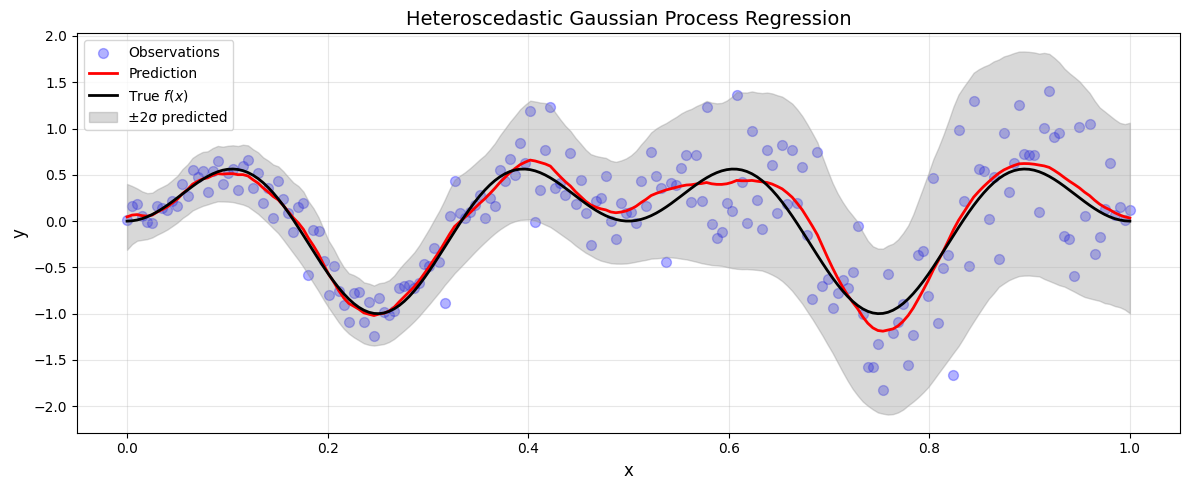

In [14]:
# Para regresión heterocedástica
fig = mogptk.model.plot_multilatent_prediction(
    model=model,
    X_train=X,
    Y_train=Y,
    X_test=X,
    f_true=f,      # Opcional: función verdadera
    sigma=2,
    title='Heteroscedastic Gaussian Process Regression'
)